# M1.Ex1: Model Hours vs Marks

- Run: [**Open In Colab**](https://colab.research.google.com/github/HassanAlgoz/B5/blob/main/content/W3/M1/exercises/ex1_reg.ipynb)
- Raw Dataset: [Rounded_Student_Hours_Studied_vs_Marks_Dataset.csv](https://raw.githubusercontent.com/HassanAlgoz/B5/main/content/datasets/Rounded_Student_Hours_Studied_vs_Marks_Dataset.csv)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

### Step 1. Load the data

In [2]:
url = "https://raw.githubusercontent.com/HassanAlgoz/B5/main/content/datasets/Rounded_Student_Hours_Studied_vs_Marks_Dataset.csv"

In [3]:
df = pd.read_csv(url)
print(df.head())

   Hours_Studied  Marks
0           4.76  46.27
1           3.00  34.30
2           2.08  33.63
3           4.04  47.81
4           9.49  66.26


### Step 2.a Assign variables `X` to the features and `y` to the target

In [4]:
X = df[['Hours_Studied']]
y = df['Marks']

### Step 2.b print the type of each

In [5]:
print(f"Type of X: {type(X)}")
print(f"Type of y: {type(y)}")

Type of X: <class 'pandas.DataFrame'>
Type of y: <class 'pandas.Series'>


### Step 2.c identify whether the target is categorical or numerical & whether the task is regression or classification

In [6]:
print("Target: Numerical, Task: Regression")

Target: Numerical, Task: Regression


### Step 3. Identify the number of samples and columns of both the data matrix and the target

In [7]:
print(f"Data Matrix (X) shape: {X.shape}")
print(f"Target (y) shape: {y.shape}")

Data Matrix (X) shape: (100, 1)
Target (y) shape: (100,)


### Step 4. Summarize the distribution of the data (min, max, median, mean, and standard deviation)

In [8]:
df.describe()

,Hours_Studied,Marks
count,100.000000,100.000000
mean,5.376300,46.360200
std,2.593013,14.284805
min,1.050000,20.190000
25%,3.175000,33.675000
50%,5.565000,47.485000
75%,7.255000,57.377500
max,9.870000,73.260000


### Step 5. Plot the feature vs the target

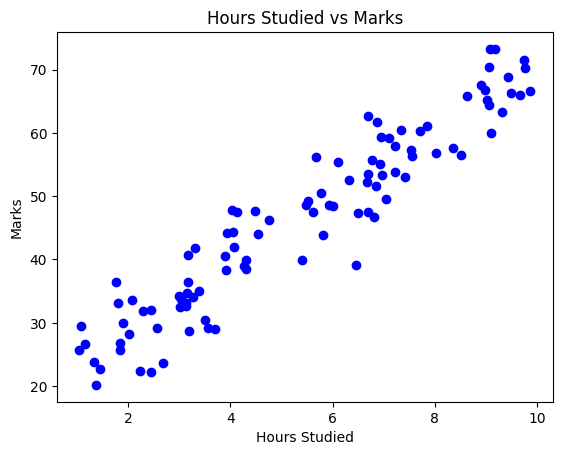

In [9]:
plt.scatter(df['Hours_Studied'], df['Marks'], color='blue')
plt.title('Hours Studied vs Marks')
plt.xlabel('Hours Studied')
plt.ylabel('Marks')
plt.show()

### Step 6. What is the relationship between the feature and the target? (increasing or decreasing or none)

In [11]:
print("Relationship: Increasing")

Relationship: Increasing


### Step 7. Initialize a `LinearRegression` model

In [12]:
model = LinearRegression()

### Step 8. Split the dataset into train and test sets

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Train size: {len(X_train)}, Test size: {len(X_test)}")

Train size: 80, Test size: 20


### Step 9.a Train the model on the training set

In [14]:
model.fit(X_train, y_train)

print("Training finished!")

Training finished!


### Step 9.b Identify the learned slope and the y-intercept of the model

In [15]:
slope = model.coef_[0]
intercept = model.intercept_

print(f"Slope (m): {slope}")
print(f"Intercept (b): {intercept}")

Slope (m): 5.164438413499556
Intercept (b): 18.538578512317276


### Step 9.c how much marks do we get per 1 hour of study?

In [16]:
print(f"Marks per 1 hour: {slope}")

Marks per 1 hour: 5.164438413499556


### Step 9.d how much does a 10 minutes increase of study time adds to our marks?

In [17]:
ten_min_increase = slope * (10/60)
print(f"Marks per 10 minutes: {ten_min_increase}")

Marks per 10 minutes: 0.8607397355832593


### Step 9.e if one doesn't study at all, how much marks do they get?

In [18]:
print(f"Marks with zero study: {intercept}")

Marks with zero study: 18.538578512317276


### Step 10. Evaluate the model on the test set

In [19]:
accuracy = model.score(X_test, y_test)
print(f"Model Accuracy (R^2): {accuracy}")

Model Accuracy (R^2): 0.9258085525213727


### Step 11. Take a sample of three rows from the test set and make a prediction on them and check whether they match the true label or not

In [20]:
X_sample = X_test.head(3)
y_true = y_test.head(3)

y_pred_sample = model.predict(X_sample)

comparison = pd.DataFrame({
    'Actual Marks': y_true.values,
    'Predicted Marks': y_pred_sample
})
print(comparison)

   Actual Marks  Predicted Marks
0         32.50        34.135183
1         67.54        64.502080
2         55.70        53.553471


### Step 12. Plot the data and the regression line

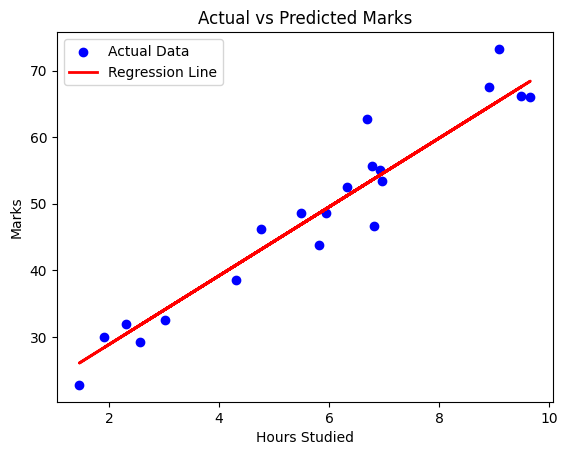

In [21]:
plt.scatter(X_test, y_test, color='blue', label='Actual Data')

plt.plot(X_test, model.predict(X_test), color='red', linewidth=2, label='Regression Line')

plt.title('Actual vs Predicted Marks')
plt.xlabel('Hours Studied')
plt.ylabel('Marks')
plt.legend()
plt.show()